# Trajectory Inference with Palantir

Using endocrine pancreas development as an example, this tutorial shows how to infer pseudotime with Palantir, inspect branch structure, summarize gene trends, and draw branch-aware pseudotime stream plots with `ov.pl.branch_streamplot`.

## Method background

See the [Palantir documentation](https://palantir.readthedocs.io/en/latest/) and the original [Nature Biotechnology paper](https://www.nature.com/articles/s41587-019-0068-4).

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=3000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=50)

🔍 [2026-05-12 15:48:18] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.08s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.49 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.3006s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (8.85s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 8.849s                                                  │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


We first inspect the variance explained by principal components to choose a practical PC range for neighbor graph construction.

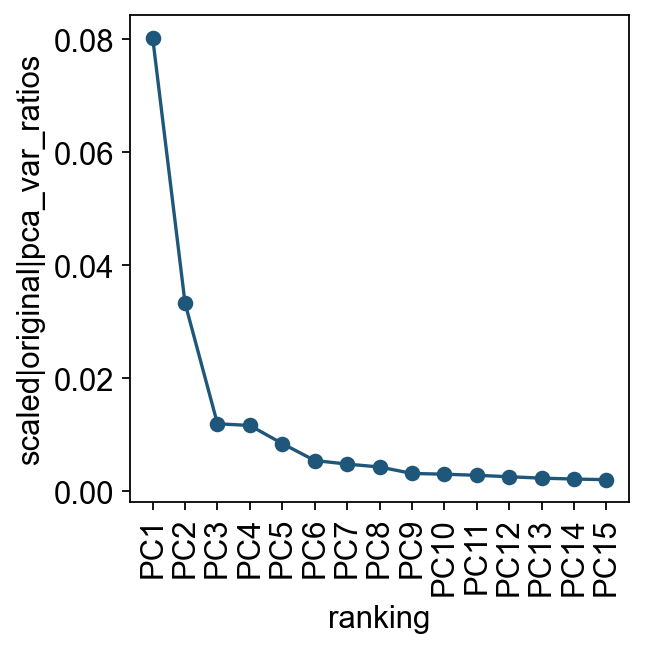

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


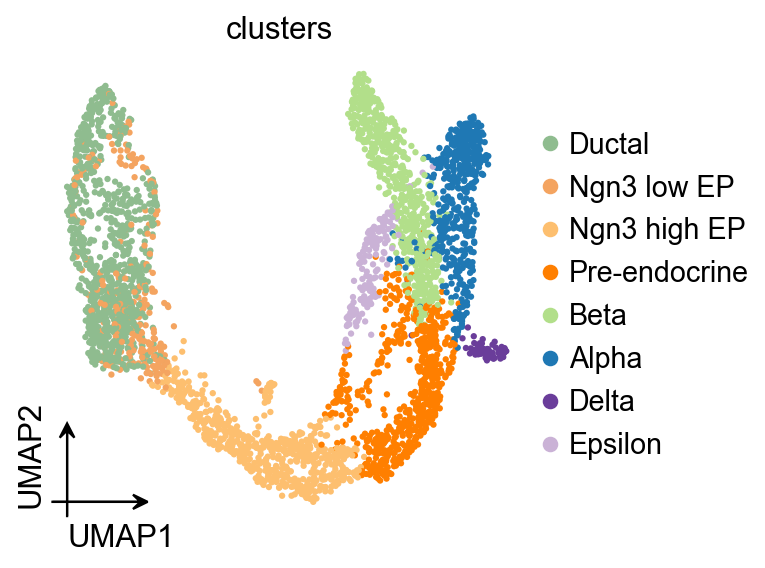

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Palantir

Palantir needs an approximate early cell. It can infer terminal states automatically; in this dataset the major terminal states are known, so we specify them through `terminal_states`. Here `ov.single.TrajInfer` is used to build the analysis object.

In [6]:
Traj=ov.single.TrajInfer(
    adata,
    basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.set_origin_cells('Ductal')
Traj.set_terminal_cells(["Alpha","Beta","Delta","Epsilon"])

In [7]:
Traj.inference(method='palantir',num_waypoints=500)

**finished identifying marker genes by COSG**
Sampling and flocking waypoints...
Time for determining waypoints: 0.00039654970169067383 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


Time for shortest paths: 0.1240071177482605 minutes
Iteratively refining the pseudotime...


Correlation at iteration 1: 0.9998


Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


Palantir results can be projected onto tSNE or UMAP with `plot_palantir_results`.

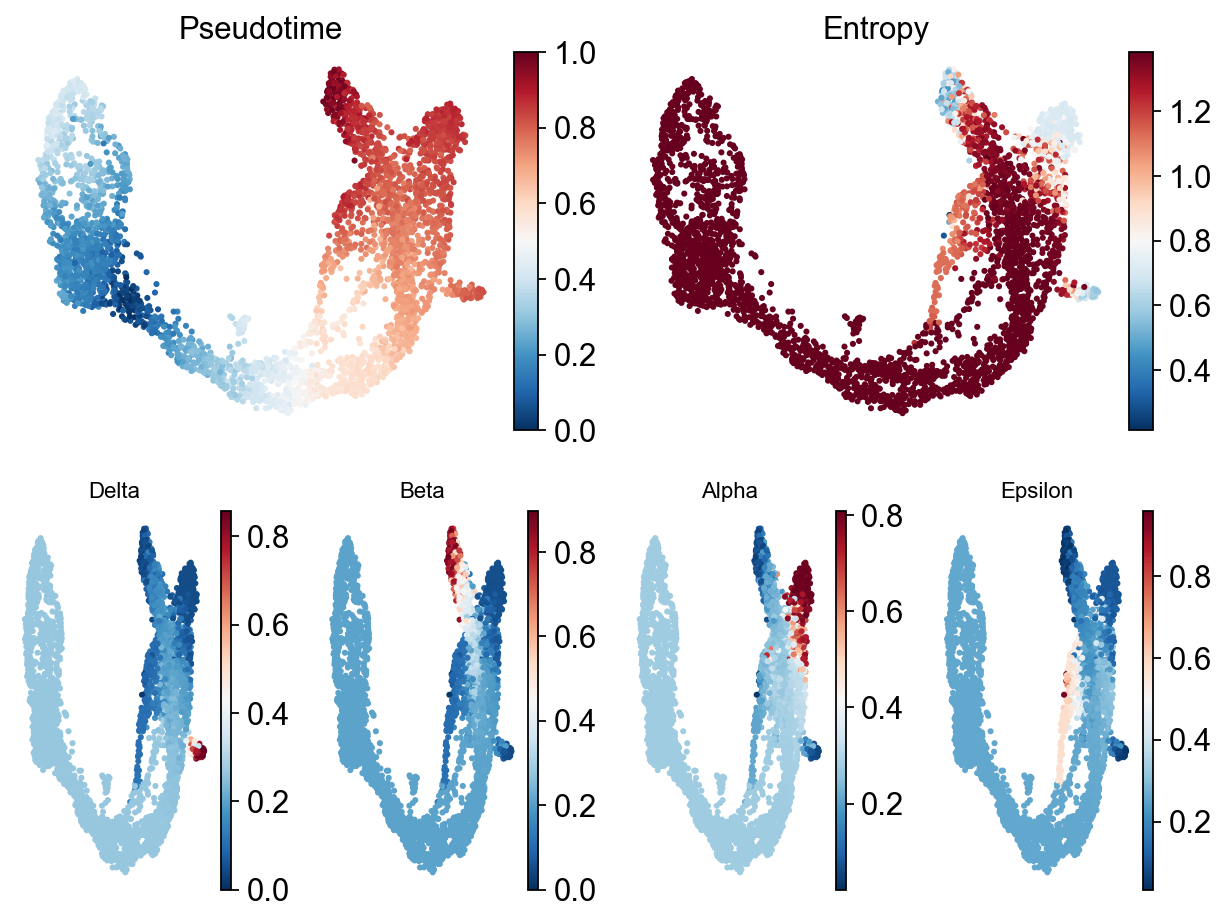

In [8]:
Traj.palantir_plot_pseudotime(
    embedding_basis='X_umap',
    cmap='RdBu_r',
    s=3,
    n_cols=4,
    figsize=(8, 6),
)

After selecting branch cells, it is useful to map them back to the pseudotime trajectory and confirm that the intended branch was selected. `plot_branch_selection` performs this check.

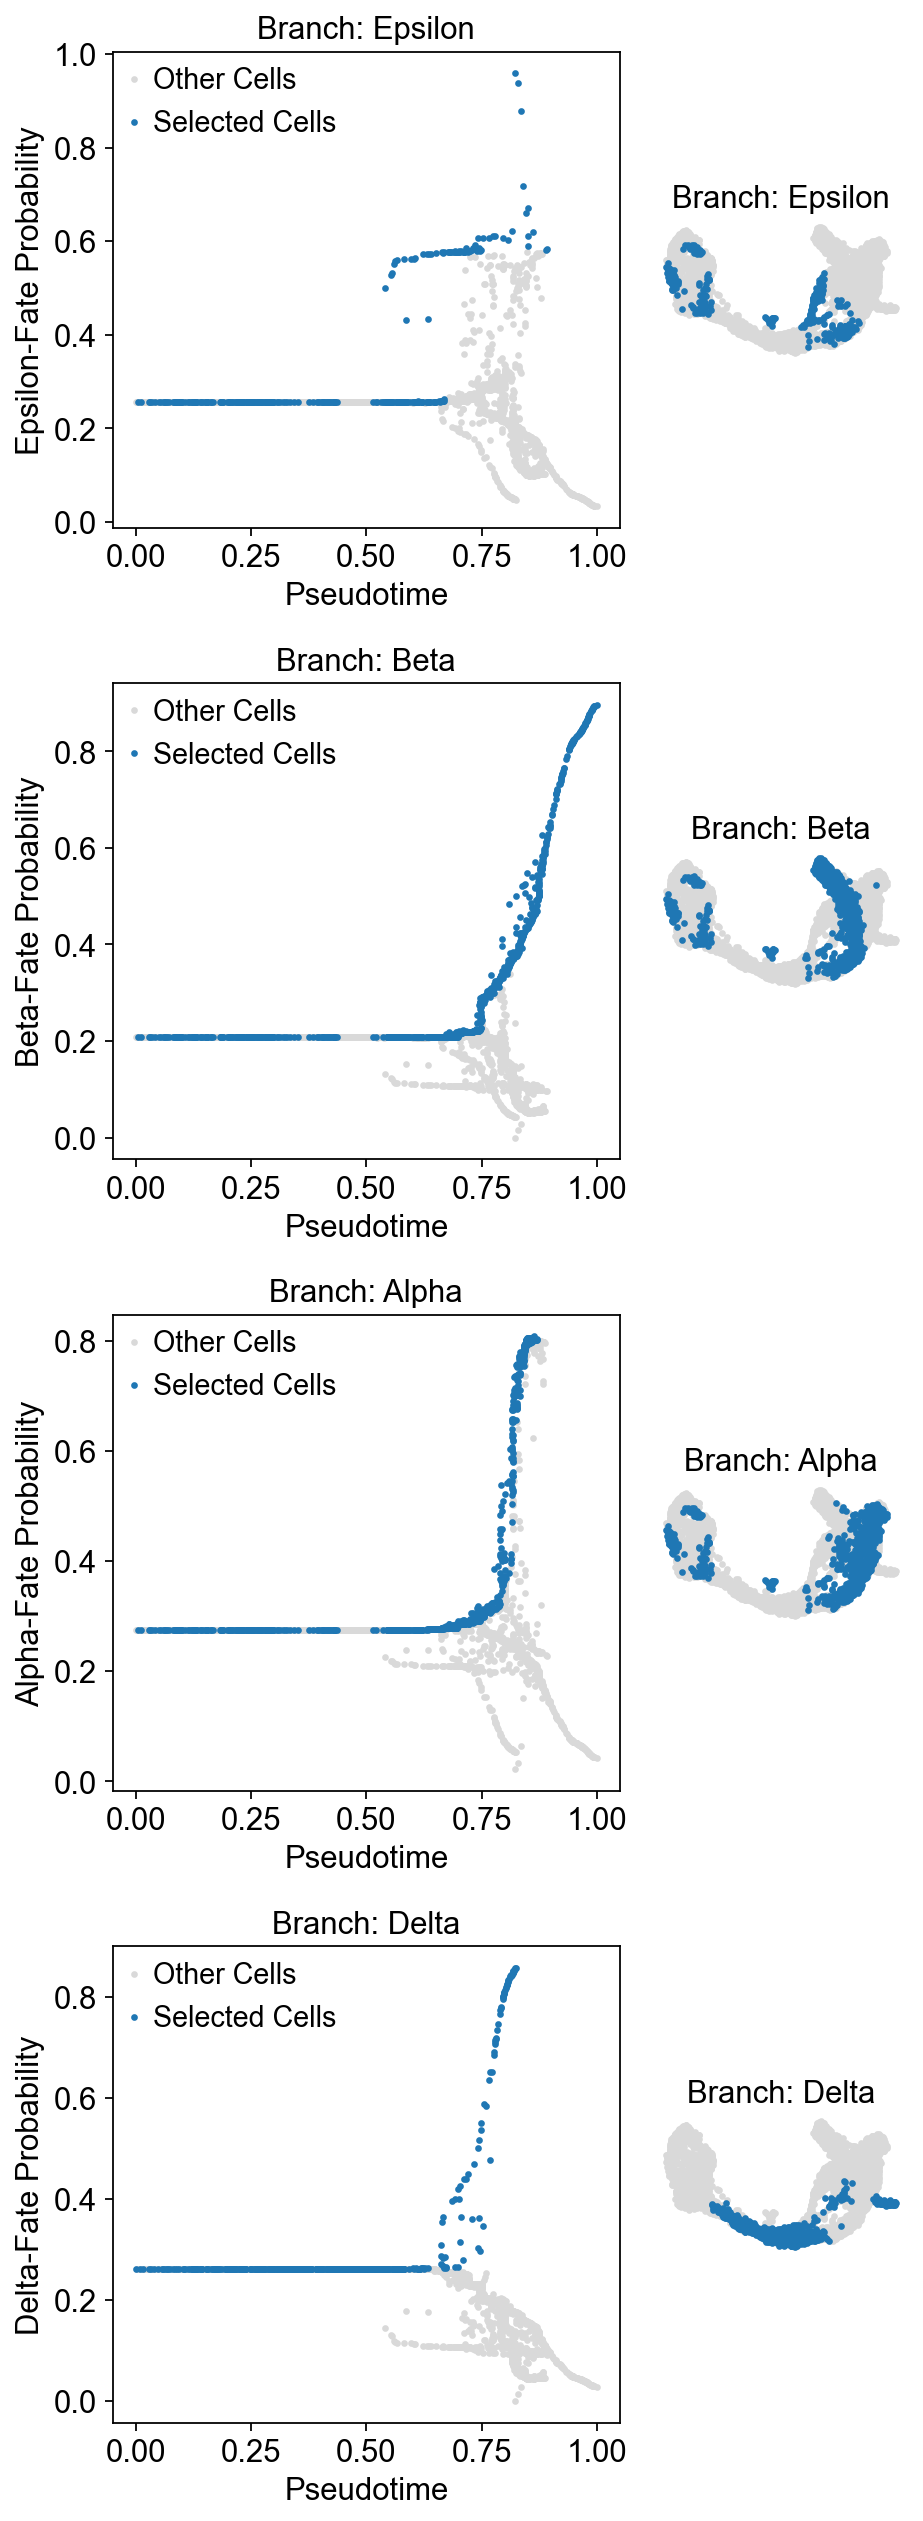

In [9]:
Traj.palantir_cal_branch(
    eps=0,
    plot_kwargs={
        'figsize': (6, 4),
        'selected_color': '#1f77b4',
        'deselected_color': '#d9d9d9',
        's': 4,
    },
)

[2026-05-12 15:48:53,998] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (805) and rank = 1.0.


[2026-05-12 15:48:53,998] [INFO    ] Using covariance function Matern52(ls=1.262711524963379).


[2026-05-12 15:48:54,026] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).


[2026-05-12 15:48:55,108] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: Alpha'}, xlabel='UMAP1', ylabel='UMAP2'>

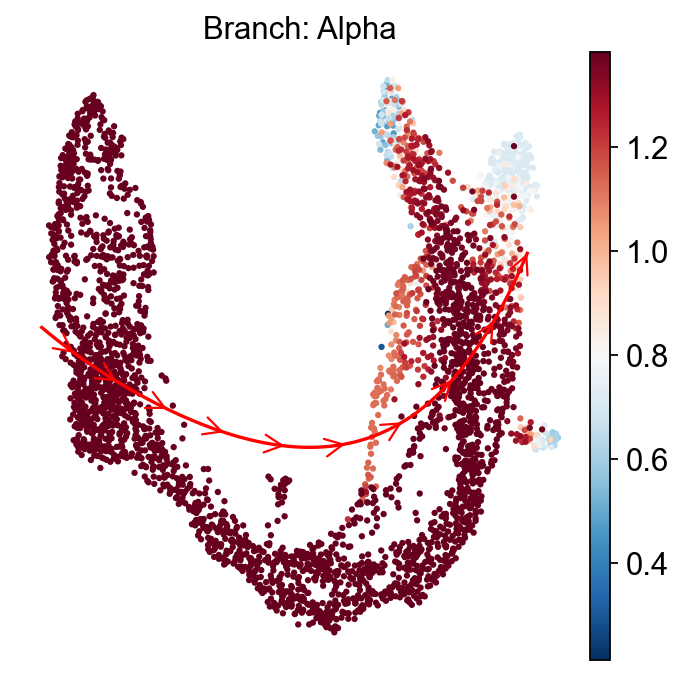

In [10]:
ov.external.palantir.plot.plot_trajectory(
    adata,
    "Alpha",
    cell_color="palantir_entropy",
    n_arrows=10,
    color="red",
    scanpy_kwargs=dict(cmap="RdBu_r"),
)

## Branch-oriented pseudotime stream plot

After computing `palantir_pseudotime`, cluster occupancy along pseudotime can be smoothed into KDE ribbons and mapped onto a compact branch skeleton. This provides a trajectory-level overview suitable for figures.

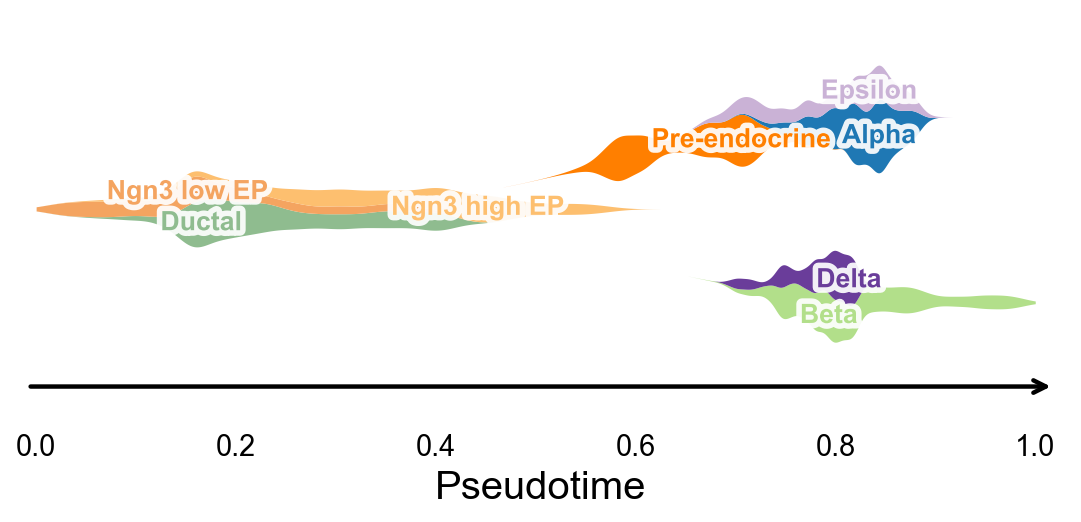

In [11]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='palantir_pseudotime',
    show=False,
)
plt.show()

Palantir uses the Mellon Function Estimator to fit gene-expression trends along lineages. The following code computes marker trends for all lineages; a subset can also be selected with the `lineages` argument.

In [13]:
adata.layers['lognorm'] = adata.X.copy()
# MAGIC currently conflicts with the NumPy version in the dev environment,
# so we keep a stable smoothed-expression placeholder layer for downstream trends/heatmaps.
adata.layers['MAGIC_imputed_data'] = adata.layers['lognorm'].copy()

In [14]:
gene_trends = Traj.palantir_cal_gene_trends(
    layers="MAGIC_imputed_data",
)

Delta
[2026-05-12 15:48:57,000] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (624) and rank = 1.0.


[2026-05-12 15:48:57,001] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-05-12 15:48:58,026] [INFO    ] Sigma interpreted as element-wise standard deviation.


Beta


[2026-05-12 15:48:58,241] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (939) and rank = 1.0.


...

[2026-05-12 15:48:58,794] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-05-12 15:48:59,159] [INFO    ] Sigma interpreted as element-wise standard deviation.


Epsilon
[2026-05-12 15:48:59,282] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (324) and rank = 1.0.


[2026-05-12 15:48:59,282] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-05-12 15:48:59,684] [INFO    ] Sigma interpreted as element-wise standard deviation.



🔍 Dynamic feature analysis:
   Views: 4 | Features: 2
   Pseudotime: palantir_pseudotime
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600

🔍 Dynamic trend plotting:
   Features: 2 | Groups: 4
   compare_features=False | compare_groups=True


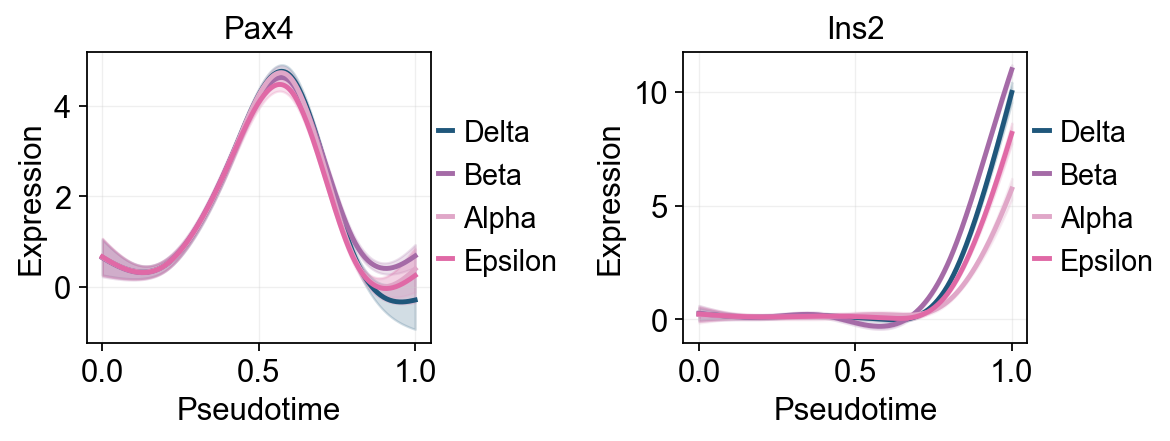

✅ Dynamic trend plotting completed!


In [15]:
Traj.palantir_plot_gene_trends(
    ['Pax4', 'Ins2'],
    layers='MAGIC_imputed_data',
    figsize=(4.5, 3),
    compare_groups=True,
    linewidth=2.2,
)
plt.show()


🔍 Dynamic feature analysis:
   Views: 2 | Features: 2
   Pseudotime: palantir_pseudotime
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 4/4
   ✓ Fitted rows: 800

🔍 Dynamic trend plotting:
   Features: 2 | Groups: 2
   compare_features=False | compare_groups=True


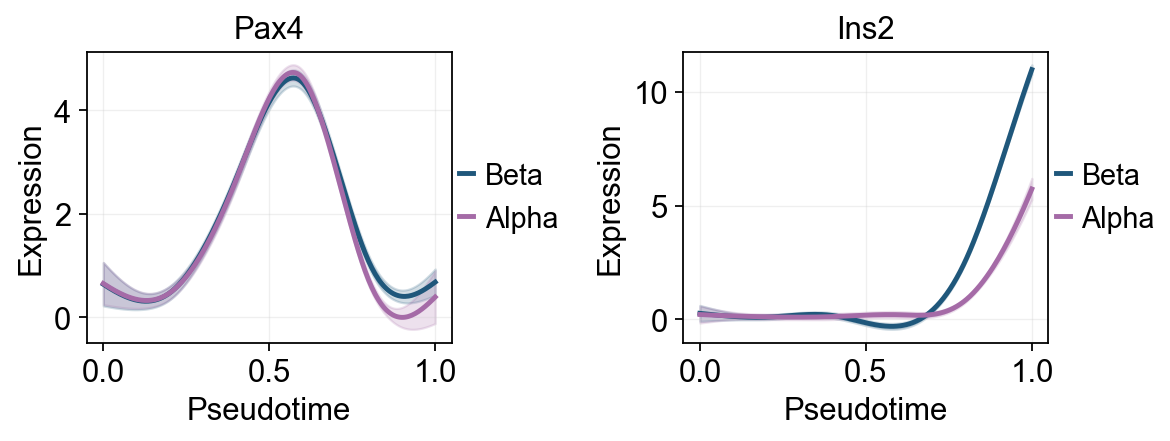

✅ Dynamic trend plotting completed!


In [16]:
Traj.palantir_plot_gene_trends(
    ['Pax4', 'Ins2'],
    lineages=['Beta', 'Alpha'],
    layers='MAGIC_imputed_data',
    figsize=(4.5, 3),
    compare_groups=True,
    linewidth=2.2,
)
plt.show()

## Fit GAM trends with `dynamic_features`

`ov.single.dynamic_features` can fit GAM trends along Palantir pseudotime. We first construct a global trend object with raw points colored by cluster, then fit late Alpha and Beta branches separately to show branch-associated expression changes.

In [17]:
dynamic_feature_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

dyn_res = ov.single.dynamic_features(
    adata,
    genes=dynamic_feature_genes,
    pseudotime='palantir_pseudotime',
    layer='MAGIC_imputed_data',
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)

dyn_res.get_stats(successful_only=True).sort_values('peak_time')


🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: palantir_pseudotime
   Stored raw obs keys: ['clusters']
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


  dataset groupby_key group     gene  success error  n_cells  exp_ncells  \
1   adata        None  None  Neurog3     True  None     3696        1569   
9   adata        None  None     Hhex     True  None     3696        1300   
0   adata        None  None     Sox9     True  None     3696        1712   
5   adata        None  None     Pax4     True  None     3696        1087   
2   adata        None  None      Fev     True  None     3696        1449   
4   adata        None  None      Arx     True  None     3696         784   
8   adata        None  None      Sst     True  None     3696         253   
3   adata        None  None      Gcg     True  None     3696         827   
6   adata        None  None     Ins2     True  None     3696         496   
7   adata        None  None     Pdx1     True  None     3696        1974   

   peak_time  valley_time  min_pseudotime  max_pseudotime        r2  \
1   0.002513     0.891960             0.0             1.0  0.285898   
9   0.138191     0.98

### Single-line Global Trends

Each gene is fitted with one global trend line while raw points are colored by cell annotation. This view helps separate the overall pseudotime expression pattern from the cell states contributing those points.


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


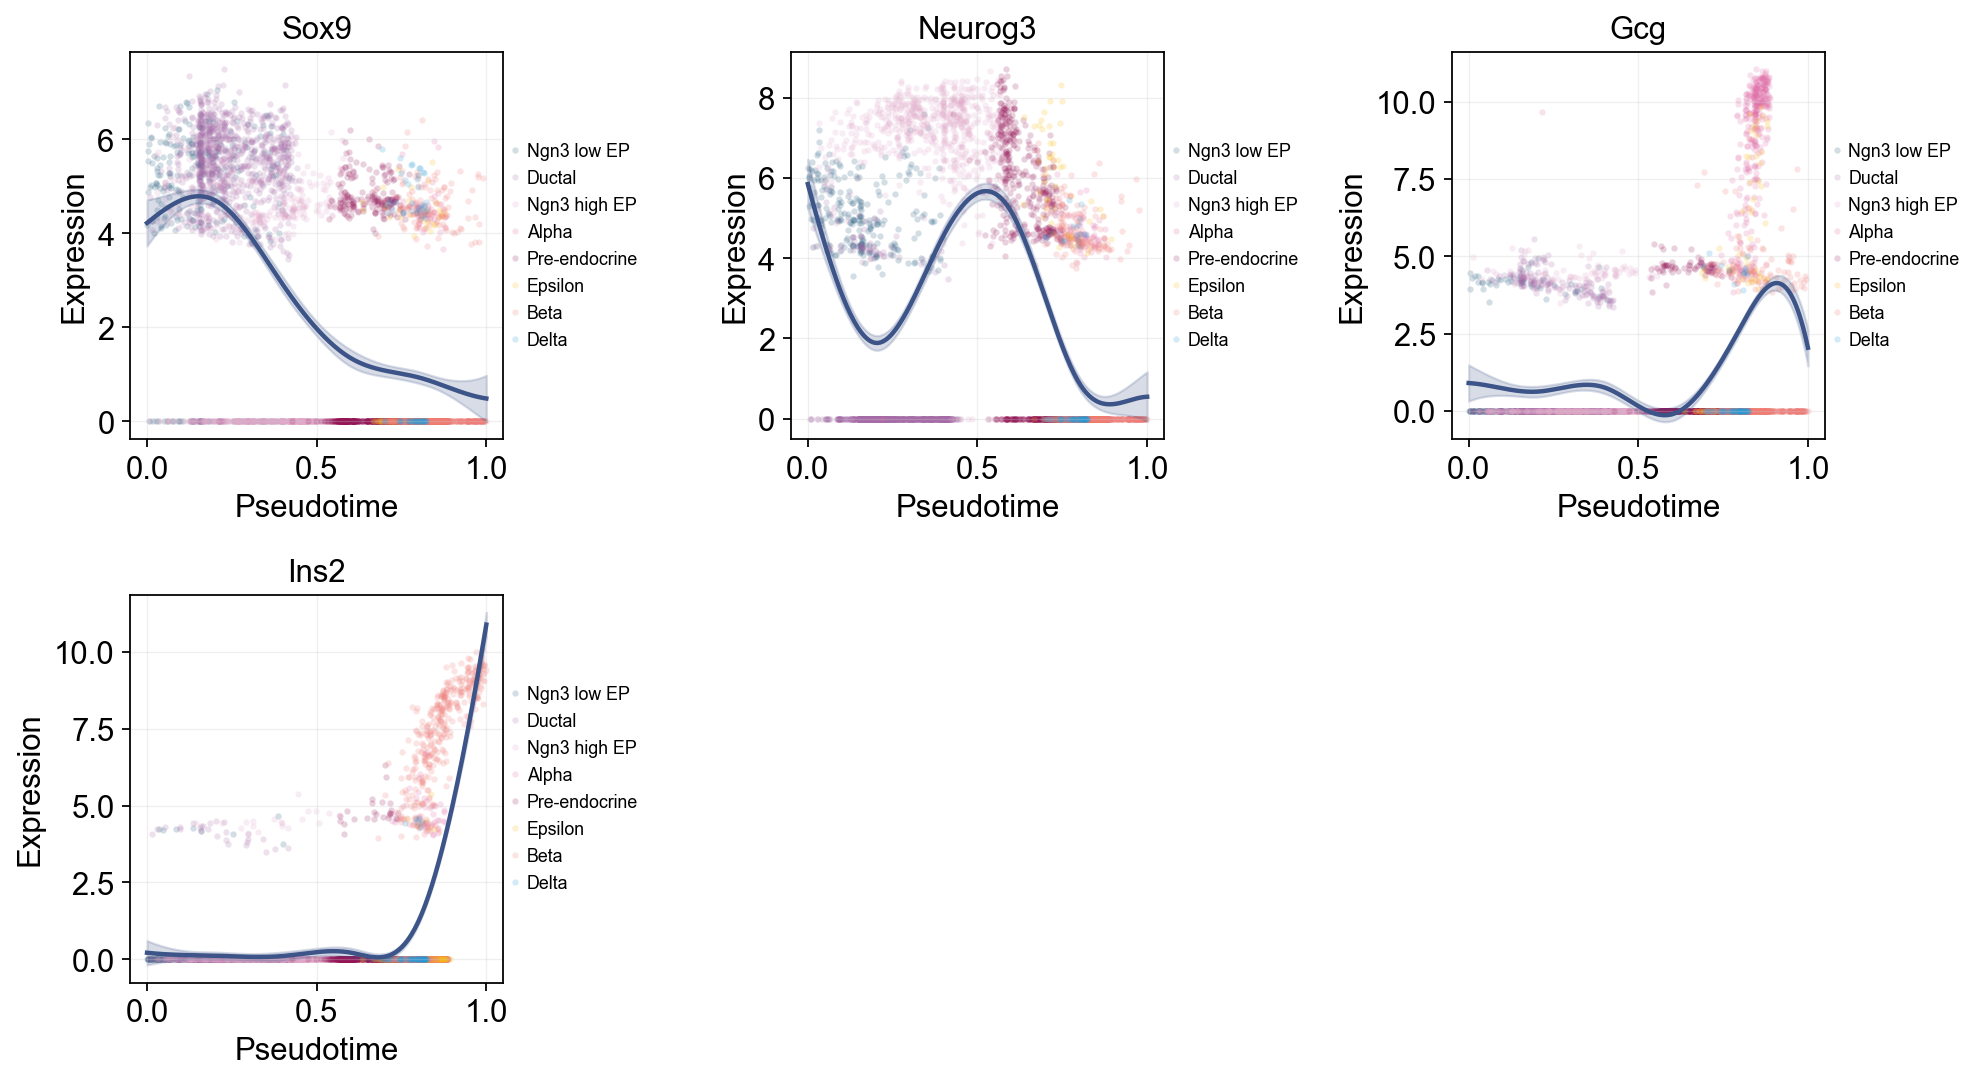

✅ Dynamic trend plotting completed!


In [18]:
ov.pl.dynamic_trends(
    dyn_res,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

### Multi-marker Trend Comparison

Multiple marker curves are overlaid on one pseudotime axis, making it easier to compare the activation and decay order of different programs.

In [19]:
selected_dynamic_genes = dyn_res.get_significant_features(
    min_expcells=20,
    r2_cutoff=0.1,
)
selected_dynamic_genes[:10]

['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Hhex']

In [20]:
branch_clusters = [g for g in ['Alpha', 'Beta'] if g in set(adata.obs['clusters'].astype(str))]

grouped_dyn_res = ov.single.dynamic_features(
    adata,
    genes=['Gcg', 'Ins2', 'Pax4', 'Sox9'],
    pseudotime='palantir_pseudotime',
    layer='MAGIC_imputed_data',
    groupby='clusters',
    groups=branch_clusters,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
grouped_dyn_res.get_stats(successful_only=True).head(8)


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: palantir_pseudotime
   Grouping: clusters
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288


  dataset groupby_key  group  gene  success error  n_cells  exp_ncells  \
0   Alpha    clusters  Alpha   Gcg     True  None      481         316   
1   Alpha    clusters  Alpha  Ins2     True  None      481          44   
2   Alpha    clusters  Alpha  Pax4     True  None      481          27   
3   Alpha    clusters  Alpha  Sox9     True  None      481          44   
4    Beta    clusters   Beta   Gcg     True  None      591         105   
5    Beta    clusters   Beta  Ins2     True  None      591         361   
6    Beta    clusters   Beta  Pax4     True  None      591         152   
7    Beta    clusters   Beta  Sox9     True  None      591         126   

   peak_time  valley_time  min_pseudotime  max_pseudotime        r2  \
0   0.886358     0.606559        0.217201        0.888043  0.563417   
1   0.795339     0.218887        0.217201        0.888043  0.001280   
2   0.515541     0.856018        0.217201        0.888043  0.095104   
3   0.576220     0.218887        0.217201        


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


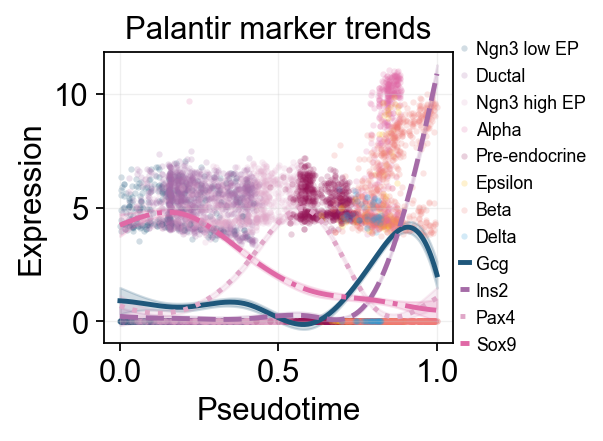

✅ Dynamic trend plotting completed!


In [21]:
palantir_compare_genes = ['Gcg', 'Ins2', 'Pax4', 'Sox9']

ov.pl.dynamic_trends(
    dyn_res,
    genes=palantir_compare_genes,
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    linewidth=2.2,
    figsize=(4.8, 3),
    legend_loc='right margin',
    legend_fontsize=8,
    title='Palantir marker trends',
)
plt.show()


🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True


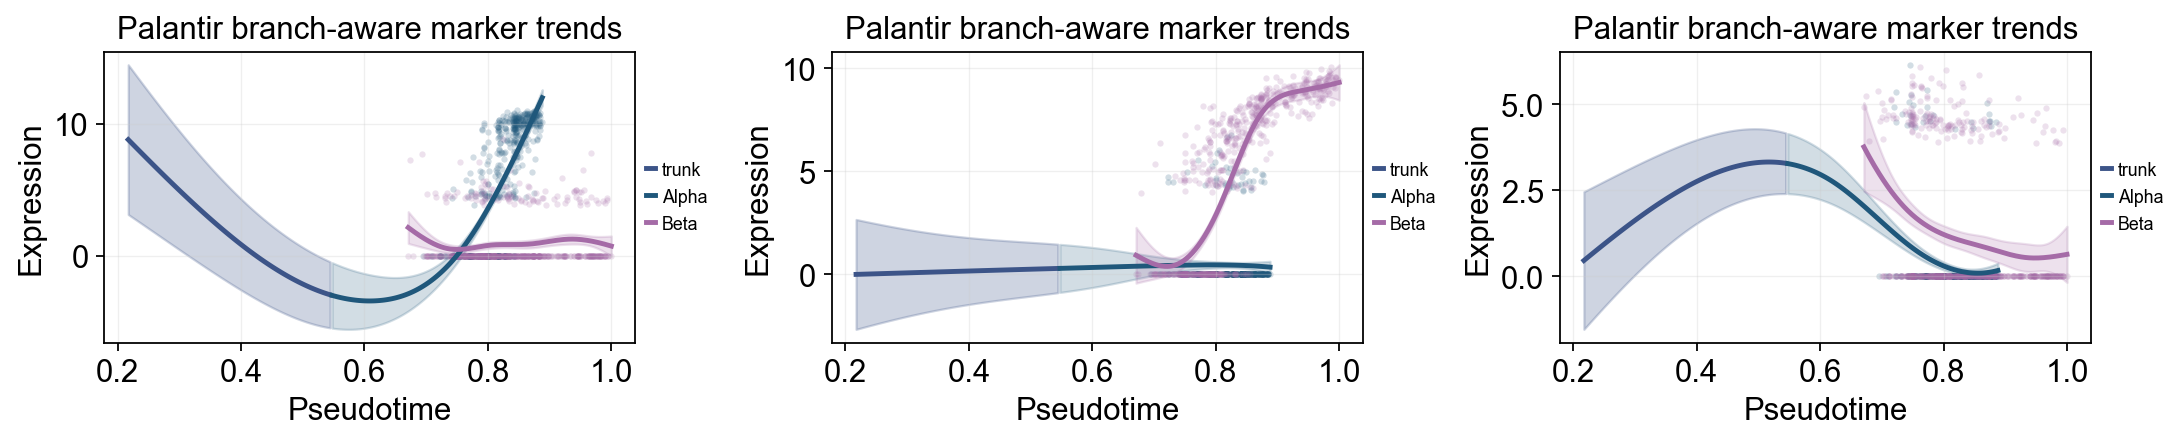

✅ Dynamic trend plotting completed!


In [22]:
palantir_split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])
palantir_split_time = float(np.nanmedian(adata.obs.loc[palantir_split_mask, 'palantir_pseudotime'])) if palantir_split_mask.any() else float(np.nanmedian(adata.obs['palantir_pseudotime']))

ov.pl.dynamic_trends(
    grouped_dyn_res,
    genes=['Gcg', 'Ins2', 'Pax4'],
    compare_groups=True,
    split_time=palantir_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(5.5, 3),
    linewidth=2.2,
    ncols=3,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Palantir branch-aware marker trends',
)
plt.show()

## Summarize Palantir trends with a dynamic heatmap

After computing `palantir_pseudotime` and `MAGIC_imputed_data`, `ov.pl.dynamic_heatmap` can summarize pancreas marker dynamics along pseudotime. Compared with single-gene trend curves, the heatmap is better for comparing the activation order of multiple lineage programs in one view.


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: palantir_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=200 | cmap=viridis



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 200 columns


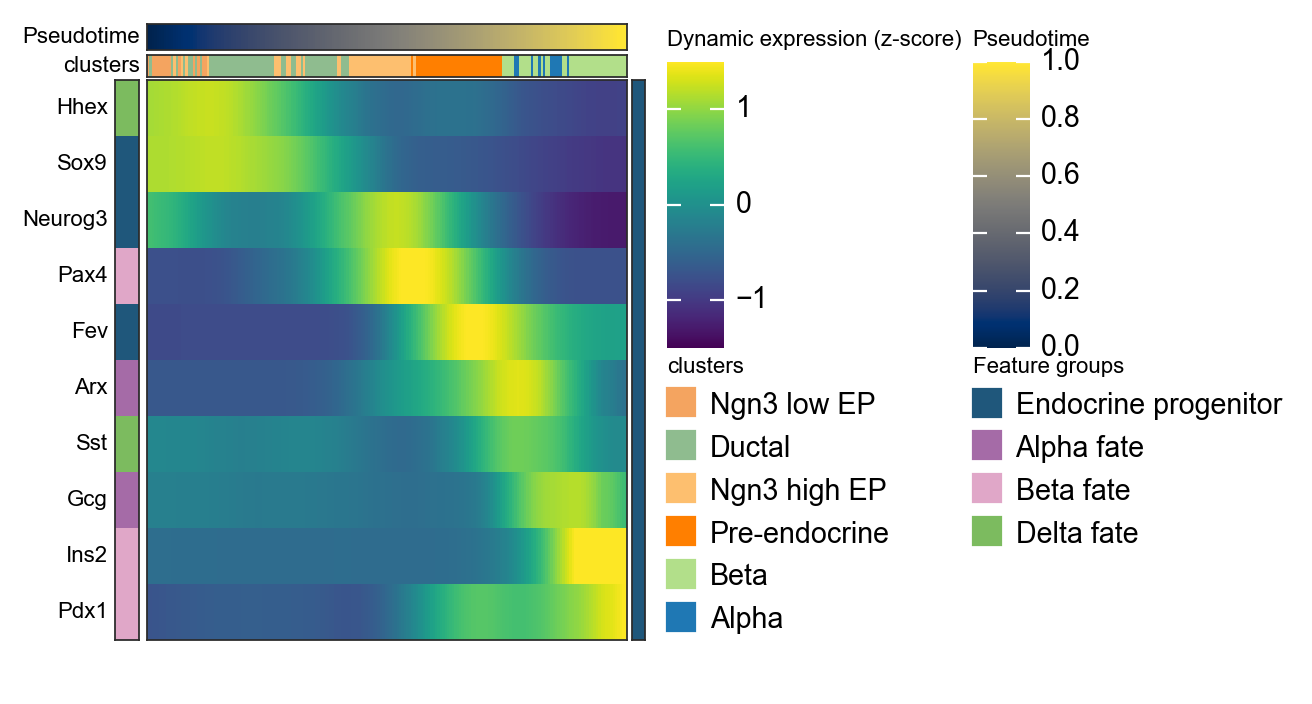

In [23]:
dynamic_marker_modules = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}

d = ov.pl.dynamic_heatmap(
    adata,
    var_names=dynamic_marker_modules,
    pseudotime='palantir_pseudotime',
    layer='MAGIC_imputed_data',
    cell_annotation='clusters',
    # Bin columns are more stable here and preserve annotation tracks.
    use_cell_columns=False,
    cell_bins=200,
    smooth_window=21,
    fitted_window=41,
    figsize=(4, 5),
    standard_scale='var',
    cmap='viridis',
    show_row_names=True,
    border=True,
    show=False,
)

PAGA can also be used to inspect cluster-level connectivity between cell states.

In [24]:
ov.utils.cal_paga(
    adata,
    use_time_prior='palantir_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['palantir_pseudotime']


    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA palantir-graph'}>

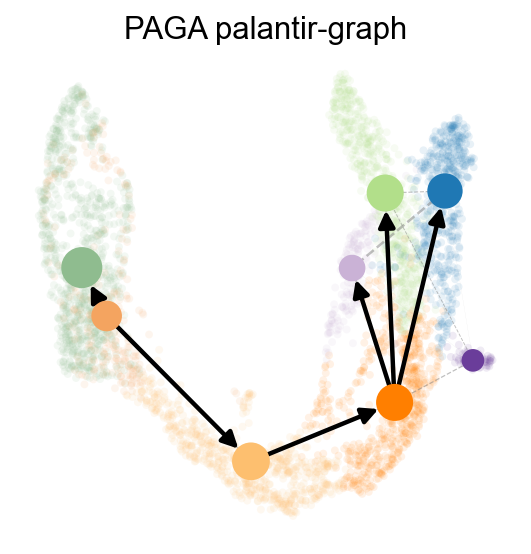

In [25]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA palantir-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)